# (1) Task description
- Translate text from Chinese to English.
- Main goal: Get familiar with transformer.

## Import package

In [1]:
import os
import json
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchsummary import summary
from timeit import default_timer as timer

from utils import *
from network import *

/nashome/NVL4/msedalab/m314510196/.pyenv/versions/3.12.11/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Fix random seed

In [2]:
def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed(5429)

# (2) Data Processing
- Original dataset is [Tatoeba](https://tatoeba.org/zh-cn/) and [XDailyDialog](https://github.com/liuzeming01/XDailyDialog)
- We select 50000 English-Chinese sentence pairs for translation task

- Args:
  - BATCH_SIZE  (You can modify)
  - data_dir: the path to the given training translation dataset

In [3]:
data_dir = "./translation_train_data.json"
BATCH_SIZE = 32

## Show the raw data

In [4]:
translation_raw_data = pd.read_json(data_dir)
display(translation_raw_data)

,English,Chinese
0,I'm Susan Greene.,我是蘇珊格林。
1,You don't have to take an examination.,你不需要考试。
2,I can't leave.,我走不了。
3,A cold beer would hit the spot!,来杯冰啤酒就太棒了!
4,Let's start!,讓我們開始吧。
...,...,...
49995,Just buy a cask of wine. Have you bought ice yet?,买一桶酒就行了。你买冰块了吗?
49996,OK. No problem.,"好的,没问题。"
49997,"I'm not really in the mood for Italian, actual...","实际上,我不太喜欢意大利菜。我想吃点辣的。"
49998,It's OK. It seems we have a lot in common.,还行吧。看来我们有很多共同点。


## Tokenization
- Tokenizer: BertTokenizer
  - encode: convert text to token ID
  - decode: convert token ID back to text

In [5]:
tokenizer_en = tokenizer_english()
tokenizer_cn = tokenizer_chinese()

In [6]:
english_seqs = translation_raw_data["English"].apply(lambda x: tokenizer_en.encode(x, add_special_tokens=True, padding=False))
chinese_seqs = translation_raw_data["Chinese"].apply(lambda x: tokenizer_cn.encode(x, add_special_tokens=True, padding=False))

MAX_TOKENIZE_LENGTH = max(english_seqs.str.len().max(), chinese_seqs.str.len().max()) # longest string
MAX_TOKENIZE_LENGTH = pow(2, math.ceil(math.log(MAX_TOKENIZE_LENGTH)/math.log(2)))    # closest upper to the power of 2

print("Max tokenize length:", MAX_TOKENIZE_LENGTH)

Max tokenize length: 128


## Add paddings
- make all the sentences the same length by inserting token ID = PAD_IDX at the back

In [7]:
#add padding
def add_padding(token_list, max_length):
    if len(token_list) < max_length:
        padding_length = max_length - len(token_list)
        token_list = token_list + [PAD_IDX] * padding_length
    else:
        token_list = token_list[:max_length]  # Trim to MAX_LENGTH if longer
    return token_list

chinese_seqs = chinese_seqs.apply(lambda x: add_padding(x, MAX_TOKENIZE_LENGTH))
english_seqs = english_seqs.apply(lambda x: add_padding(x, MAX_TOKENIZE_LENGTH))

In [8]:
# check the padding result
print("=====Chinese tokenized data=====")
print(chinese_seqs.iloc[0])

print("=====English tokenized data=====")
print(english_seqs.iloc[0])

=====Chinese tokenized data=====
[101, 2769, 3221, 5979, 4396, 3419, 3360, 511, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
=====English tokenized data=====
[101, 146, 112, 182, 5640, 10983, 119, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## Datalodader
- Split dataset into training dataset(90%) and validation dataset(10%). You can modify the traning/validation ratio
- Create dataloader to iterate the data.

In [9]:
data_size = len(translation_raw_data)
train_size = int(0.9*data_size)
valid_size = data_size - train_size
print("train size:", train_size)
print("valid size:", valid_size)

en_train_data = []
cn_train_data = []
en_valid_data = []
cn_valid_data = []

for i in range(data_size):
    if (i < train_size):
        en_train_data.append(torch.Tensor(english_seqs.iloc[i]))
        cn_train_data.append(torch.Tensor(chinese_seqs.iloc[i]))
    else:
        en_valid_data.append(torch.Tensor(english_seqs.iloc[i]))
        cn_valid_data.append(torch.Tensor(chinese_seqs.iloc[i]))

class TextTranslationDataset(Dataset): 
    def __init__(self, src, dst): 
        self.src_list = src
        self.dst_list = dst
        
    def __len__(self): 
        return len(self.src_list)

    def __getitem__(self, idx): 
        return self.src_list[idx], self.dst_list[idx]
        
cn_to_en_train_set = TextTranslationDataset(cn_train_data, en_train_data)
cn_to_en_valid_set = TextTranslationDataset(cn_valid_data, en_valid_data)

cn_to_en_train_loader = DataLoader(cn_to_en_train_set, batch_size=BATCH_SIZE, shuffle=False)
cn_to_en_valid_loader = DataLoader(cn_to_en_valid_set, batch_size=BATCH_SIZE, shuffle=True)

train size: 45000
valid size: 5000


# (3) Model
- **TO-DO**: Finish the model in "network.py"
    - You can first write code here for convenience, but note that <span style='color:red'>**TA will test your model using model definition in "network.py"**</span><p>
- Base transformer layers in [Attention Is All You Need](https://arxiv.org/abs/1706.03762)
    - TransformerEncoderLayer:
    - TransformerDecoderLayer:
- Positional encoding and input embedding
- Note that you may need masks when implementing attention mechanism
    - Padding mask: prevent input from attending to padding tokens
    - Causal mask: prevent decoder input from attending to future input

In [10]:
model = load_model()

for p in model.parameters():
    if p.dim() > 1:
        nn.init.xavier_uniform_(p)

model = model.to(DEVICE)
param_model = sum(p.numel() for p in model.parameters())
print (f"The parameter size of model is {param_model/1000} k")

The parameter size of model is 25814.34 k


# (4) Training
- You can change the training setting by yourself including
  - Number of epoch
  - Optimizer
  - Learning rate
  - Learning rate scheduler
  - etc...

In [11]:
NUM_EPOCHS = 40
WARMUP_STEPS = 8000
D_MODEL = 256
loss_fn = torch.nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1, betas=(0.9, 0.98), eps=1e-9,weight_decay=1e-5)

## Training and Evaluation Functions

In [12]:
def get_lr(step, d_model, warmup_steps):
    # 論文中的 LR scheduler
    # 確保 step 從 1 開始，避免除以 0
    if step == 0:
        step = 1
    arg1 = step ** -0.5
    arg2 = step * (warmup_steps ** -1.5)
    return (d_model ** -0.5) * min(arg1, arg2)
    
def train_epoch(model, optimizer, train_dataloader, global_step):
    model.train()
    losses = 0
        
    for src, tgt in train_dataloader:
        # src, tgt shape: (batch_size, seq_length)
        global_step += 1
        lr = get_lr(global_step, D_MODEL, WARMUP_STEPS)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)            
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]
        
        logits = model(src, tgt_input)
        
        optimizer.zero_grad()
        loss = loss_fn(logits.reshape(-1, logits.shape[-1]), tgt_output.reshape(-1).long())
        loss.backward()
        optimizer.step()
        losses += loss.item()
    
    return global_step, (losses / len(list(train_dataloader)))


def evaluate(model, val_dataloader):
    model.eval()
    losses = 0
    score = 0
    
    for src, tgt in val_dataloader:
        # src, tgt shape: (batch_size, seq_length)
        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)

        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]
        
        logits = model(src, tgt_input)
        _, tgt_predict = torch.max(logits, dim=-1)
        score_batch = BLEU_batch(tgt_predict, tgt_output, tokenizer_en)

        loss = loss_fn(logits.reshape(-1, logits.shape[-1]), tgt_output.reshape(-1).long())
        losses += loss.item()
        score += score_batch

    return (losses / len(list(val_dataloader))), (score / len(list(val_dataloader)))

## Start training
- MODEL_SAVE_PATH: path for storing the best model

In [13]:
MODEL_SAVE_PATH = "./model.ckpt"

In [14]:
model = model.to(DEVICE)

best_acc = 0
global_step = 0
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': []
}
for epoch in range(1, NUM_EPOCHS+1):
    start_time = timer()
    global_step, train_loss = train_epoch(model, optimizer, cn_to_en_train_loader, global_step)
    end_time = timer()
    val_loss, val_acc = evaluate(model, cn_to_en_valid_loader)
    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print((f"Epoch: {epoch}, Train loss: {train_loss:.3f}, Val loss: {val_loss:.3f}, Val Acc: {val_acc:.3f}, "f"Epoch time = {(end_time - start_time):.3f}s, LR = {current_lr:.6f}"))

    # Save the best model so far.
    if val_acc > best_acc: 
        best_acc = val_acc
        best_state_dict = model.state_dict()
        torch.save(best_state_dict, MODEL_SAVE_PATH)
        print(f"(model saved at epoch {epoch})")

Epoch: 1, Train loss: 7.214, Val loss: 5.577, Val Acc: 0.067, Epoch time = 122.857s, LR = 0.000123
(model saved at epoch 1)
Epoch: 2, Train loss: 5.101, Val loss: 5.038, Val Acc: 0.174, Epoch time = 110.569s, LR = 0.000246
(model saved at epoch 2)
Epoch: 3, Train loss: 4.668, Val loss: 4.662, Val Acc: 0.266, Epoch time = 109.576s, LR = 0.000369
(model saved at epoch 3)
Epoch: 4, Train loss: 4.315, Val loss: 4.359, Val Acc: 0.366, Epoch time = 109.573s, LR = 0.000492
(model saved at epoch 4)
Epoch: 5, Train loss: 4.043, Val loss: 4.163, Val Acc: 0.439, Epoch time = 109.708s, LR = 0.000614
(model saved at epoch 5)
Epoch: 6, Train loss: 3.872, Val loss: 4.033, Val Acc: 0.473, Epoch time = 116.611s, LR = 0.000680
(model saved at epoch 6)
Epoch: 7, Train loss: 3.725, Val loss: 3.924, Val Acc: 0.513, Epoch time = 151.926s, LR = 0.000630
(model saved at epoch 7)
Epoch: 8, Train loss: 3.591, Val loss: 3.834, Val Acc: 0.542, Epoch time = 109.252s, LR = 0.000589
(model saved at epoch 8)
Epoch: 9

--- 正在繪製當次訓練結果 ---


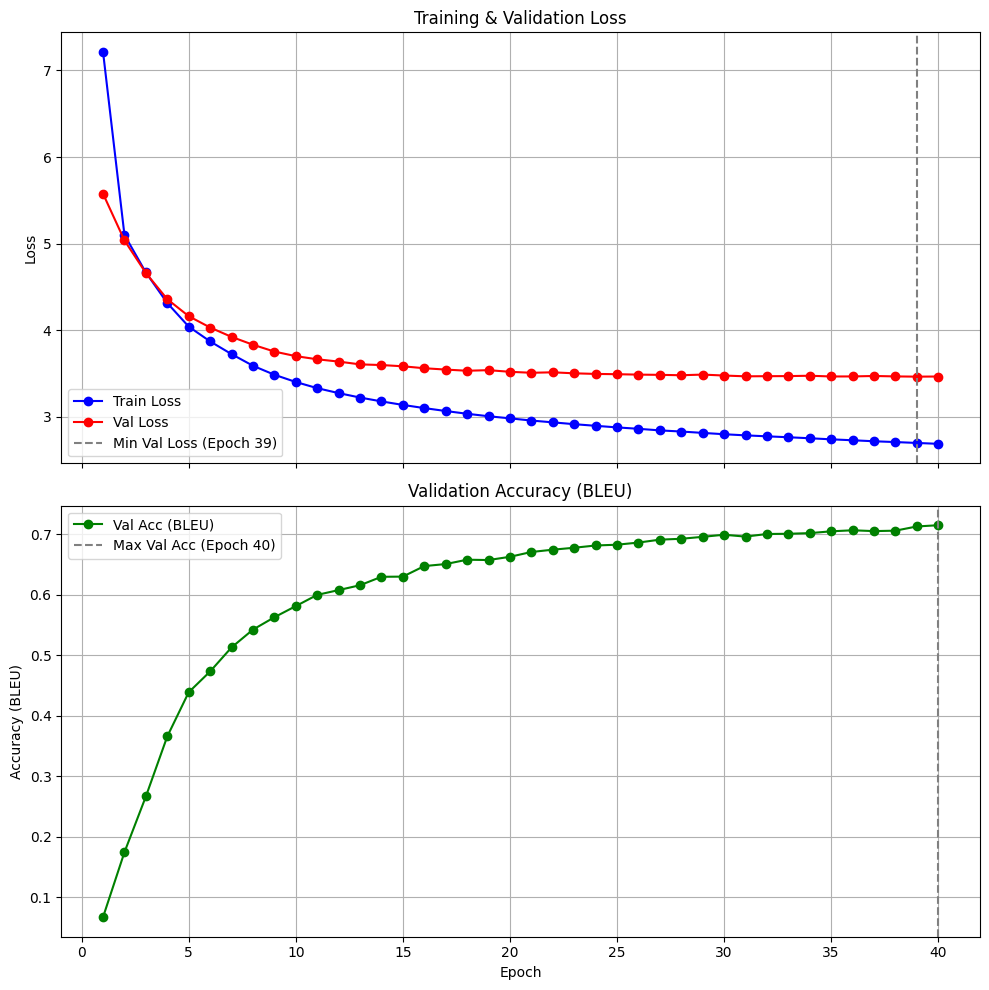

In [15]:
import matplotlib.pyplot as plt
import numpy as np

print("--- 正在繪製當次訓練結果 ---")

# 從 'history' 字典中獲取數據
train_losses = history['train_loss']
val_losses = history['val_loss']
val_accs = history['val_acc']

# 動態產生 Epoch 數量
epochs = np.arange(1, len(train_losses) + 1)

# 建立一個 2x1 的子圖
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# 繪製第一張圖: 訓練 & 驗證損失
ax1.plot(epochs, train_losses, 'bo-', label='Train Loss')
ax1.plot(epochs, val_losses, 'ro-', label='Val Loss')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.grid(True)

# 標記 Val Loss 最低點
if val_losses: # 確保列表不為空
    min_val_loss_epoch = np.argmin(val_losses) + 1
    ax1.axvline(x=min_val_loss_epoch, color='grey', linestyle='--', label=f'Min Val Loss (Epoch {min_val_loss_epoch})')
ax1.legend()

# 繪製第二張圖: 驗證準確率 (BLEU)
ax2.plot(epochs, val_accs, 'go-', label='Val Acc (BLEU)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (BLEU)')
ax2.set_title('Validation Accuracy (BLEU)')
ax2.grid(True)

# 標記 Val Acc 最高點
if val_accs: # 確保列表不為空
    max_val_acc_epoch = np.argmax(val_accs) + 1
    ax2.axvline(x=max_val_acc_epoch, color='grey', linestyle='--', label=f'Max Val Acc (Epoch {max_val_acc_epoch})')
ax2.legend()

# 顯示圖表
plt.tight_layout()
plt.show()

# (5) Inference

In [16]:
from utils import *
from network import *

In [17]:
tokenizer_en = tokenizer_english()
tokenizer_cn = tokenizer_chinese()

## Load best model

In [18]:
model = load_model(MODEL_PATH="model.ckpt")
model = model.to(DEVICE)

/nashome/NVL4/msedalab/m314510196/DL/2025_DL_Lab03/network.py:468: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH))


## Translation testing
 - **TO-DO**: Finish the "translate" function in "network.py"
   - You can first write code here for convenience, but note that <span style='color:red'>**TA will test your model using "translate" function in "network.py"**</span>

In [19]:
sentence = "你好，欢迎来到中国。"
ground_truth = 'Hello, welcome to China.'
predicted = translate(model, sentence, tokenizer_cn, tokenizer_en)

print(f'{"Input:":15s}: {sentence}')
print(f'{"Prediction":15s}: {predicted}')
print(f'{"Ground truth":15s}: {ground_truth}')
print("Bleu Score (1-gram): ", bleu_score_func(predicted.lower(), ground_truth.lower(), 1).item())
print("Bleu Score (2-gram): ", bleu_score_func(predicted.lower(), ground_truth.lower(), 2).item())
print("Bleu Score (3-gram): ", bleu_score_func(predicted.lower(), ground_truth.lower(), 3).item())
print("Bleu Score (4-gram): ", bleu_score_func(predicted.lower(), ground_truth.lower(), 4).item())

Input:         : 你好，欢迎来到中国。
Prediction     : You're so popular to China.
Ground truth   : Hello, welcome to China.
Bleu Score (1-gram):  0.4000000059604645
Bleu Score (2-gram):  0.3162277638912201
Bleu Score (3-gram):  0.0
Bleu Score (4-gram):  0.0


In [20]:
sentence = "她知道您的電話號碼嗎?"
ground_truth = 'Does she know your telephone number?'
predicted = translate(model, sentence, tokenizer_cn, tokenizer_en)

print(f'{"Input:":15s}: {sentence}')
print(f'{"Prediction":15s}: {predicted}')
print(f'{"Ground truth":15s}: {ground_truth}')
print("Bleu Score (1gram): ", bleu_score_func(predicted.lower(), ground_truth.lower(), 1).item())
print("Bleu Score (2gram): ", bleu_score_func(predicted.lower(), ground_truth.lower(), 2).item())
print("Bleu Score (3gram): ", bleu_score_func(predicted.lower(), ground_truth.lower(), 3).item())
print("Bleu Score (4gram): ", bleu_score_func(predicted.lower(), ground_truth.lower(), 4).item())

Input:         : 她知道您的電話號碼嗎?
Prediction     : Does she know your phone number?
Ground truth   : Does she know your telephone number?
Bleu Score (1gram):  0.8333333134651184
Bleu Score (2gram):  0.7071067690849304
Bleu Score (3gram):  0.6299605369567871
Bleu Score (4gram):  0.5372849702835083


In [21]:
sentence = "你现在在哪里工作?"
ground_truth = 'Where do you work now?'
predicted = translate(model, sentence, tokenizer_cn, tokenizer_en)

print(f'{"Input:":15s}: {sentence}')
print(f'{"Prediction":15s}: {predicted}')
print(f'{"Ground truth":15s}: {ground_truth}')
print("Bleu Score (1gram): ", bleu_score_func(predicted.lower(), ground_truth.lower(), 1).item())
print("Bleu Score (2gram): ", bleu_score_func(predicted.lower(), ground_truth.lower(), 2).item())
print("Bleu Score (3gram): ", bleu_score_func(predicted.lower(), ground_truth.lower(), 3).item())
print("Bleu Score (4gram): ", bleu_score_func(predicted.lower(), ground_truth.lower(), 4).item())

Input:         : 你现在在哪里工作?
Prediction     : Where do you work right now?
Ground truth   : Where do you work now?
Bleu Score (1gram):  0.8333333134651184
Bleu Score (2gram):  0.7071067690849304
Bleu Score (3gram):  0.6299605369567871
Bleu Score (4gram):  0.5372849702835083
